# Steam Rating Predictor
Krzysztof Boryczka, Adam Ciężkowski, Artur Krzyżyński

Our goal in this project is to build a model that predicts Steam game ratings. To achieve this, we experiment with KNeighborsRegressor, PCA, and several other classical approaches.

In [89]:
import pandas as pd
import numpy as np
import scipy

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from tqdm import tqdm

from collections import Counter

import json

np.random.seed(1234)

For convenience, we start by preparing an enum-like structure for the dataset columns.

In [90]:
class Param:
    def add(self, param_name, column_name):
        column_name = column_name.lower().replace(" ", "_")

        if param_name in self.__dict__:
            raise ValueError(f'Param "{param_name}" is already used.')

        self.__dict__[param_name] = column_name

    def delete(self, param_name):
        del self.__dict__[param_name]

    def crop(self, df):
        return df[[p for p in self.__dict__.values() if p in df.columns]]


param = Param()

param.add("RELEASE_DATE", "release_date")
param.add("ESTIMATED_OWNERS", "estimated_owners")
param.add("PRICE", "price")
param.add("DLC_COUNT", "dlc_count")
param.add("SUPPORTED_LANGUAGES", "supported_languages")
param.add("WINDOWS", "windows")
param.add("MAC", "mac")
param.add("LINUX", "linux")
param.add("POSITIVE", "positive")
param.add("NEGATIVE", "negative")
param.add("ACHIEVEMENTS", "achievements")
param.add("RECOMMENDATIONS", "recommendations")
param.add("AVERAGE_PLAYTIME_FOREVER", "average_playtime_forever")
param.add("MEDIAN_PLAYTIME_FOREVER", "median_playtime_forever")
param.add("DEVELOPERS", "developers")
param.add("PUBLISHERS", "publishers")
param.add("CATEGORIES", "categories")
param.add("GENRES", "genres")
param.add("TAGS", "tags")

### Loading and Parsing Data

We created a custom separator for list-valued fields because developer and publisher names can contain characters such as "," and ";".

In [91]:
BAD_VALUES = ["n/a", "none", "na"]
SEPARATOR = "[;;;] "

LIST_PARAMS = [
    param.SUPPORTED_LANGUAGES,
    param.DEVELOPERS,
    param.PUBLISHERS,
    param.CATEGORIES,
    param.GENRES,
    param.TAGS,
]

OTHER_PARAMS = [
    param.RELEASE_DATE,
    param.ESTIMATED_OWNERS,
    param.PRICE,
    param.DLC_COUNT,
    param.WINDOWS,
    param.MAC,
    param.LINUX,
    param.POSITIVE,
    param.NEGATIVE,
    param.ACHIEVEMENTS,
    param.RECOMMENDATIONS,
    param.AVERAGE_PLAYTIME_FOREVER,
    param.MEDIAN_PLAYTIME_FOREVER,
]


def ls_to_str(ls):
    ls = [el for el in ls if el and el.lower() not in BAD_VALUES]
    return SEPARATOR.join(ls) if ls else np.nan


def gen_data_dict(data):
    res = {}

    for el in LIST_PARAMS:
        res[el] = ls_to_str(data[el])

    for el in OTHER_PARAMS:
        res[el] = data[el]

    return res

In [92]:
with open("games.json") as f:
    json_data = json.load(f)
    all_games = [gen_data_dict(v) for v in json_data.values()]

full_data = pd.DataFrame(all_games)

In [94]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
full_data.head(5)

,supported_languages,developers,publishers,categories,genres,tags,release_date,estimated_owners,price,dlc_count,windows,mac,linux,positive,negative,achievements,recommendations,average_playtime_forever,median_playtime_forever
0,English,Perpetual FX Creative,Perpetual FX Creative,Single-player[;;;] Multi-player[;;;] Steam Ach...,Casual[;;;] Indie[;;;] Sports,Indie[;;;] Casual[;;;] Sports[;;;] Bowling,"Oct 21, 2008",0 - 20000,19.99,0,True,False,False,6,11,30,0,0,0
1,English[;;;] French[;;;] Italian[;;;] German[;...,Rusty Moyher,Wild Rooster,Single-player[;;;] Steam Achievements[;;;] Ful...,Action[;;;] Indie,Indie[;;;] Action[;;;] Pixel Graphics[;;;] 2D[...,"Oct 12, 2017",0 - 20000,0.99,0,True,True,False,53,5,12,0,0,0
2,English[;;;] Portuguese - Brazil,Campião Games,Campião Games,Single-player,Action[;;;] Adventure[;;;] Indie[;;;] Strategy,NaN,"Nov 17, 2021",0 - 20000,4.99,0,True,False,False,0,0,0,0,0,0
3,English[;;;] French[;;;] Italian[;;;] German[;...,Odd Critter Games,Odd Critter Games,Single-player[;;;] Full controller support,Adventure[;;;] Casual[;;;] Indie,2D Platformer[;;;] Atmospheric[;;;] Surreal[;;...,"Jul 23, 2020",0 - 20000,5.99,0,True,True,True,3,0,0,0,0,0
4,English[;;;] Spanish - Spain,Unusual Games,Unusual Games,Single-player[;;;] Steam Achievements,Adventure[;;;] Indie,Indie[;;;] Adventure[;;;] Nudity[;;;] Violent[...,"Feb 3, 2020",0 - 20000,0.00,0,True,True,False,50,8,17,0,0,0


### Data Preprocessing

Our target is a Steam game's rating, defined as the positive-to-total reviews ratio. To support this, we remove records with incomplete data or too few reviews, and then normalize the selected features.

In [95]:
MIN_NO_OF_REVIEWS = 50

df = param.crop(full_data)
df = df[df[param.NEGATIVE] + df[param.POSITIVE] >= MIN_NO_OF_REVIEWS]
df = df.dropna()

df.head(5)

,release_date,estimated_owners,price,dlc_count,supported_languages,windows,mac,linux,positive,negative,achievements,recommendations,average_playtime_forever,median_playtime_forever,developers,publishers,categories,genres,tags
1,"Oct 12, 2017",0 - 20000,0.99,0,English[;;;] French[;;;] Italian[;;;] German[;...,True,True,False,53,5,12,0,0,0,Rusty Moyher,Wild Rooster,Single-player[;;;] Steam Achievements[;;;] Ful...,Action[;;;] Indie,Indie[;;;] Action[;;;] Pixel Graphics[;;;] 2D[...
4,"Feb 3, 2020",0 - 20000,0.00,0,English[;;;] Spanish - Spain,True,True,False,50,8,17,0,0,0,Unusual Games,Unusual Games,Single-player[;;;] Steam Achievements,Adventure[;;;] Indie,Indie[;;;] Adventure[;;;] Nudity[;;;] Violent[...
5,"Feb 26, 2021",50000 - 100000,0.00,0,English,True,False,False,87,49,0,0,0,0,7Road,7Road,Single-player[;;;] Multi-player[;;;] MMO[;;;] ...,Adventure[;;;] Casual[;;;] Free to Play[;;;] M...,Turn-Based Combat[;;;] Massively Multiplayer[;...
8,"Apr 2, 2020",0 - 20000,14.99,0,English[;;;] French[;;;] Italian[;;;] German[;...,True,False,False,76,6,25,0,0,0,Growing Seeds,"CFK Co., Ltd.",Single-player[;;;] Steam Achievements[;;;] Ful...,Adventure[;;;] RPG[;;;] Simulation[;;;] Strategy,Adventure[;;;] Simulation[;;;] RPG[;;;] Strate...
9,"Nov 11, 2014",50000 - 100000,3.99,0,English[;;;] Polish[;;;] French[;;;] Italian[;...,True,True,True,225,45,32,0,703,782,ONE MORE LEVEL,ONE MORE LEVEL,Single-player[;;;] Steam Achievements[;;;] Ste...,Action[;;;] Adventure[;;;] Indie,Action[;;;] Indie[;;;] Adventure[;;;] Puzzle-P...


Here, we normalize the values. Since the feature scales can differ significantly in magnitude, we apply both linear and logarithmic normalization.

In [96]:
def fix_param_values(df, param, fn):
    new_df = df.copy()
    new_df[param] = df[param].map(fn)
    return new_df


def get_average(range):
    l, r = range.split("-")
    return (int(l) + int(r)) / 2.0


def remove_days_from_date(date):
    parts = date.split()
    if len(parts) == 3:
        return f"{parts[0]} {parts[2]}"
    return date


def normalize_min(df, column_name):
    new_df = df.copy()

    mini = new_df[column_name].min()
    maxi = new_df[column_name].max()

    diff = maxi - mini

    new_df[column_name] -= mini
    new_df[column_name] /= diff

    return new_df


def normalize_log(df, column_name):
    new_df = df.copy()

    maxi = np.log(new_df[column_name].max() + 1.0)
    new_df[column_name] = np.log(new_df[column_name] + 1.0) / maxi

    return new_df

In [97]:
df2 = df.copy()
df2 = fix_param_values(df2, param.ESTIMATED_OWNERS, get_average)
df2 = fix_param_values(df2, param.RELEASE_DATE, remove_days_from_date)

param.add("RELEASE_YEAR", "Release year")
param.add("RELEASE_MONTH", "Release month")

df2[param.RELEASE_DATE] = pd.to_datetime(df2[param.RELEASE_DATE], format="%b %Y")
df2[param.RELEASE_MONTH] = df2[param.RELEASE_DATE].dt.month
df2[param.RELEASE_YEAR] = df2[param.RELEASE_DATE].dt.year

param.delete("RELEASE_DATE")
df2 = param.crop(df2)

param.add("RATING", "Rating")
df2[param.RATING] = df2[param.POSITIVE] / (df2[param.POSITIVE] + df2[param.NEGATIVE])

param.delete("POSITIVE")
param.delete("NEGATIVE")
df2 = param.crop(df2)

df2.head(5)


,estimated_owners,price,dlc_count,supported_languages,windows,mac,linux,achievements,recommendations,average_playtime_forever,median_playtime_forever,developers,publishers,categories,genres,tags,release_year,release_month,rating
1,10000.0,0.99,0,English[;;;] French[;;;] Italian[;;;] German[;...,True,True,False,12,0,0,0,Rusty Moyher,Wild Rooster,Single-player[;;;] Steam Achievements[;;;] Ful...,Action[;;;] Indie,Indie[;;;] Action[;;;] Pixel Graphics[;;;] 2D[...,2017,10,0.913793
4,10000.0,0.00,0,English[;;;] Spanish - Spain,True,True,False,17,0,0,0,Unusual Games,Unusual Games,Single-player[;;;] Steam Achievements,Adventure[;;;] Indie,Indie[;;;] Adventure[;;;] Nudity[;;;] Violent[...,2020,2,0.862069
5,75000.0,0.00,0,English,True,False,False,0,0,0,0,7Road,7Road,Single-player[;;;] Multi-player[;;;] MMO[;;;] ...,Adventure[;;;] Casual[;;;] Free to Play[;;;] M...,Turn-Based Combat[;;;] Massively Multiplayer[;...,2021,2,0.639706
8,10000.0,14.99,0,English[;;;] French[;;;] Italian[;;;] German[;...,True,False,False,25,0,0,0,Growing Seeds,"CFK Co., Ltd.",Single-player[;;;] Steam Achievements[;;;] Ful...,Adventure[;;;] RPG[;;;] Simulation[;;;] Strategy,Adventure[;;;] Simulation[;;;] RPG[;;;] Strate...,2020,4,0.926829
9,75000.0,3.99,0,English[;;;] Polish[;;;] French[;;;] Italian[;...,True,True,True,32,0,703,782,ONE MORE LEVEL,ONE MORE LEVEL,Single-player[;;;] Steam Achievements[;;;] Ste...,Action[;;;] Adventure[;;;] Indie,Action[;;;] Indie[;;;] Adventure[;;;] Puzzle-P...,2014,11,0.833333


Next, we one-hot encode the categorical variables. Because there are many distinct values, we keep only the most frequent ones.

In [98]:
min_values = {
    param.CATEGORIES: 500,
    param.TAGS: 1000,
    param.DEVELOPERS: 30,
    param.PUBLISHERS: 50,
    param.SUPPORTED_LANGUAGES: 150,
    param.GENRES: 100,
}

# Split before fitting preprocessing parameters to avoid leakage.
df_train_raw, df_test_raw = train_test_split(df2, test_size=0.2, random_state=42)
df_train_raw, df_paraml_raw = train_test_split(df_train_raw, test_size=0.2, random_state=24)

log_columns = [
    param.ESTIMATED_OWNERS,
    param.DLC_COUNT,
    param.ACHIEVEMENTS,
    param.RECOMMENDATIONS,
    param.AVERAGE_PLAYTIME_FOREVER,
    param.MEDIAN_PLAYTIME_FOREVER,
    param.PRICE,
]

minmax_columns = [param.RELEASE_YEAR, param.RELEASE_MONTH]

log_max_values = {}
for column in log_columns:
    max_log = np.log(df_train_raw[column].max() + 1.0)
    log_max_values[column] = max_log if max_log > 0 else 1.0

minmax_values = {}
for column in minmax_columns:
    minmax_values[column] = (df_train_raw[column].min(), df_train_raw[column].max())

good_values = {p: set() for p in min_values.keys()}

for p in min_values.keys():
    s = []
    for z in df_train_raw[p]:
        for l in z.split(SEPARATOR):
            s.append(l.strip())

    counter = Counter(s)
    for k, v in counter.items():
        if v >= min_values[p]:
            good_values[p].add(k)

    print(p, len(good_values[p]))


def apply_normalization(df_input):
    df_out = df_input.copy()

    for column in log_columns:
        max_log = log_max_values[column]
        df_out[column] = np.log(df_out[column] + 1.0) / max_log

    for column in minmax_columns:
        mini, maxi = minmax_values[column]
        diff = maxi - mini
        if diff == 0:
            df_out[column] = 0.0
        else:
            df_out[column] = (df_out[column] - mini) / diff

    return df_out


def leave_good(param_name):
    allowed_values = good_values[param_name]

    def fn(ls):
        ls = set(map(str.strip, ls.split(SEPARATOR)))
        new_ls = ls.intersection(allowed_values)
        if new_ls:
            return SEPARATOR.join(sorted(new_ls))
        return "NONE"

    return fn


def prepare_features(df_input):
    df3 = apply_normalization(df_input)

    for p in min_values.keys():
        df3[p] = df3[p].apply(leave_good(p))

    pom = []
    for p in min_values.keys():
        for val in sorted(good_values[p]):
            pom.append(df3[p].str.contains(val, regex=False).to_frame(name=val))

    res = pd.concat((df3, *pom), axis=1)
    res = res.drop(columns=list(min_values.keys()))
    res = res.astype(float)

    X_data = res.drop(columns=[param.RATING]).to_numpy()
    y_data = res[param.RATING].to_numpy()

    return X_data, y_data, res


X_train, y_train, train_res = prepare_features(df_train_raw)
X_paraml, y_paraml, param_res = prepare_features(df_paraml_raw)
X_test, y_test, test_res = prepare_features(df_test_raw)

train_res.head(5)

categories 23
tags 50
developers 3
publishers 23
supported_languages 29
genres 13


,estimated_owners,price,dlc_count,windows,mac,linux,achievements,recommendations,average_playtime_forever,median_playtime_forever,release_year,release_month,rating,Co-op,Cross-Platform Multiplayer,Full controller support,In-App Purchases,Includes level editor,Multi-player,Online Co-op,Online PvP,Partial Controller Support,PvP,Remote Play Together,Remote Play on TV,Remote Play on Tablet,Shared/Split Screen,Shared/Split Screen Co-op,Shared/Split Screen PvP,Single-player,Stats,Steam Achievements,Steam Cloud,Steam Leaderboards,Steam Trading Cards,Steam Workshop,2D,3D,Action,Action-Adventure,Adventure,Anime,Arcade,Atmospheric,Casual,Co-op,Colorful,Comedy,Cute,Difficult,Early Access,Exploration,FPS,Family Friendly,Fantasy,Female Protagonist,First-Person,Free to Play,Funny,Gore,Great Soundtrack,Horror,Indie,Multiplayer,Nudity,Open World,Pixel Graphics,Platformer,Point & Click,Psychological Horror,Puzzle,RPG,Relaxing,Retro,Sandbox,Sci-fi,Sexual Content,Shooter,Simulation,Singleplayer,Story Rich,Strategy,Survival,Third Person,Violent,Visual Novel,Feral Interactive (Mac),"KOEI TECMO GAMES CO., LTD.",Square Enix,2K,Artifex Mundi,BANDAI NAMCO Entertainment,Daedalic Entertainment,Devolver Digital,Disney,Electronic Arts,Fulqrum Publishing,"KOEI TECMO GAMES CO., LTD.",Kagura Games,Microids,Nacon,Nightdive Studios,PLAYISM,PlayWay S.A.,Plug In Digital,SEGA,Sekai Project,Slitherine Ltd.,Square Enix,THQ Nordic,Ubisoft,tinyBuild,Arabic,Bulgarian,Czech,Danish,Dutch,English,Finnish,French,German,Greek,Hungarian,Italian,Japanese,Korean,Norwegian,Polish,Portuguese,Portuguese - Brazil,Romanian,Russian,Simplified Chinese,Spanish - Latin America,Spanish - Spain,Swedish,Thai,Traditional Chinese,Turkish,Ukrainian,Vietnamese,Action,Adventure,Casual,Early Access,Free to Play,Indie,Massively Multiplayer,RPG,Racing,Simulation,Sports,Strategy,Violent
52689,0.718566,0.662848,0.149474,1.0,0.0,0.0,0.498802,0.551047,0.572642,0.571470,0.851852,0.727273,0.742201,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
32764,0.755384,0.701816,0.000000,1.0,0.0,0.0,0.484554,0.674403,0.664342,0.637459,0.888889,0.363636,0.930252,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25628,0.489237,0.427874,0.000000,1.0,1.0,1.0,0.291745,0.354620,0.000000,0.000000,0.703704,0.272727,0.935897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6181,0.596259,0.427874,0.000000,1.0,1.0,1.0,0.540678,0.358647,0.000000,0.000000,0.666667,0.000000,0.800847,1.0,1.0,0.0,0.0,0.0,1.0,0.0,

In [99]:
def err(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


def evaluate_predictions(y_true, y_pred):
    residuals = y_true - y_pred
    mse = err(y_pred, y_true)
    avg_diff = np.abs(residuals).mean()
    return mse, avg_diff, residuals


def show_regression_report(y_true, y_pred, title, bins=100):
    mse, avg_diff, residuals = evaluate_predictions(y_true, y_pred)

    print("MSE =", mse)
    print("Avg diff =", avg_diff)

    plt.title(title)
    plt.hist(residuals, bins=bins)
    plt.show()


def fit_predict_evaluate(model, X_train, y_train, X_test, y_test, title, bins=100):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return show_regression_report(y_test, y_pred, title, bins=bins)


We apply PCA to reduce feature dimensionality.

In [100]:
COMPS = 100
pca = PCA(n_components=COMPS)
pca.fit(X_train)

X_trn_pca = pca.transform(X_train)
X_tpl_pca = pca.transform(X_paraml)

We use KNeighborsRegressor as the core of our approach and optimize it using mean squared error (MSE).

In [101]:
def run(X_train, X_test, y_train, y_test):
    def fn(w):
        knn = KNeighborsRegressor(n_neighbors=50)
        knn.fit(X_train * w, y_train)
        y_pred = knn.predict(X_test * w)

        return err(y_test, y_pred)

    return fn


fn = run(X_trn_pca, X_tpl_pca, y_train, y_paraml)
print(fn(np.ones(COMPS)))

0.021991673780792156


To optimize the alpha scaling parameters, we first tried built-in optimizers, but most of them performed poorly. We therefore switched to a classical evolutionary approach. Below is a modified and extended version of that algorithm, tailored to our task.

In [102]:
def obj_fun(arr):
    res = np.zeros(len(arr))
    for i in range(len(arr)):
        res[i] = -fn(arr[i])
    return res


def normalize(arr):
    res = np.zeros(arr.shape)
    for i in range(len(arr)):
        pom = np.clip(arr[i], 0, 10000000)
        res[i] = (pom / pom.sum()) * len(arr[i]) * 100
    return res


def es(
    objective_function,
    chromosome_length,
    population_size,
    number_of_iterations,
    number_of_offspring,
    number_of_parents,
    sigma,
    tau,
    tau_0,
):
    best_solution = np.empty((1, chromosome_length))
    best_solution_objective_value = -np.inf

    # generating an initial population
    current_population_solutions = normalize(
        100 * chromosome_length * np.random.rand(population_size, chromosome_length)
    )
    current_population_sigmas = sigma * np.ones((population_size, chromosome_length))

    # evaluating the objective function on the current population
    current_population_objective_values = objective_function(current_population_solutions)

    for t in tqdm(range(number_of_iterations)):
        # selecting the parent indices by the roulette wheel method
        fitness_values = current_population_objective_values - current_population_objective_values.min()
        if fitness_values.sum() > 0:
            fitness_values = fitness_values / fitness_values.sum()
        else:
            fitness_values = 1.0 / population_size * np.ones(population_size)
        parent_indices = np.random.choice(
            population_size, (number_of_offspring, number_of_parents), True, fitness_values
        ).astype(np.int64)

        # creating the children population by Global Intermediere Recombination
        children_population_solutions = np.zeros((number_of_offspring, chromosome_length))
        children_population_sigmas = np.zeros((number_of_offspring, chromosome_length))
        for i in range(number_of_offspring):
            children_population_solutions[i, :] = current_population_solutions[parent_indices[i, :], :].mean(axis=0)
            children_population_sigmas[i, :] = current_population_sigmas[parent_indices[i, :], :].mean(axis=0)

        # mutating the children population by adding random gaussian noise
        children_population_sigmas = children_population_sigmas * np.exp(
            tau * np.random.randn(number_of_offspring, chromosome_length)
            + tau_0 * np.random.randn(number_of_offspring, 1)
        )
        children_population_solutions = normalize(
            children_population_solutions
            + children_population_sigmas * np.random.randn(number_of_offspring, chromosome_length)
        )

        # evaluating the objective function on the children population
        children_population_objective_values = objective_function(children_population_solutions)

        # replacing the current population by (Mu + Lambda) Replacement
        current_population_objective_values = np.hstack(
            (current_population_objective_values, children_population_objective_values)
        )
        current_population_solutions = np.vstack((current_population_solutions, children_population_solutions))
        current_population_sigmas = np.vstack((current_population_sigmas, children_population_sigmas))

        I = np.argsort(current_population_objective_values)[::-1]
        current_population_solutions = current_population_solutions[I[:population_size], :].copy()
        current_population_sigmas = current_population_sigmas[I[:population_size], :].copy()
        current_population_objective_values = current_population_objective_values[I[:population_size]].copy()

        # recording some statistics
        if best_solution_objective_value < current_population_objective_values[0]:
            best_solution = current_population_solutions[0, :].reshape(1, -1)
            best_solution_objective_value = current_population_objective_values[0]

        if t % 50 == 0:
            print(-best_solution_objective_value)
            print(current_population_sigmas)
            print(best_solution)

    return -best_solution_objective_value, best_solution

Below are the results from the best-performing built-in optimization functions.

In [79]:
scipy.optimize.minimize(fn, np.random.rand(COMPS), method="L-BFGS-B")

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.022204793126857896
        x: [ 2.859e-01  9.867e-01 ...  2.260e-01  3.042e-01]
      nit: 0
      jac: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
     nfev: 101
     njev: 1
 hess_inv: <100x100 LbfgsInvHessProduct with dtype=float64>

In [53]:
scipy.optimize.differential_evolution(fn, [(0, 1)] * COMPS)

 message: Optimization terminated successfully.
 success: True
     fun: 0.02098136513681507
       x: [ 3.438e-01  5.630e-01 ...  5.907e-01  4.791e-01]
     nit: 2
    nfev: 921

Here is the result of our custom evolutionary algorithm.

In [20]:
k = 1 / 4
es(obj_fun, COMPS, 50, 1500, 100, 2, 40.0, k / np.sqrt(2 * COMPS), k / np.sqrt(2 * np.sqrt(COMPS)))

  0%|          | 1/1500 [00:18<7:31:37, 18.08s/it]

0.11691326064909709
[[36.84978382 36.07912163 37.40558199 ... 37.07038565 37.13310487
  36.8852383 ]
 [40.         40.         40.         ... 40.         40.
  40.        ]
 [42.25566437 42.53142444 42.27873779 ... 41.37358179 40.68947344
  41.18716985]
 ...
 [38.79495536 39.15630855 39.35146803 ... 39.39961256 39.12433045
  39.47768612]
 [41.38535839 41.37165595 40.61513722 ... 42.26962368 40.38746201
  39.83710021]
 [34.6157138  35.7532562  35.40825746 ... 34.75609818 34.27955809
  35.29136496]]
[[1.80228369e+02 1.15001510e+02 1.14970077e+02 2.53355953e+02
  1.48019107e+02 1.23148087e+02 1.16513899e+02 1.12807346e+02
  1.89004864e+02 1.59933811e+02 1.65963788e+02 7.55861233e+01
  7.32078739e+01 7.64655514e+01 1.64793100e+02 8.41874303e+01
  7.68272101e+01 1.22889530e+02 1.61079779e+02 1.21957671e+02
  1.69805512e+02 9.13968911e+01 5.33690587e+01 2.24482154e+01
  1.41433617e+02 7.35292642e+01 9.01331929e+01 0.00000000e+00
  5.94074131e+01 3.97052847e+01 1.60945082e+02 4.45911491e+01


  3%|▎         | 51/1500 [18:07<8:20:54, 20.74s/it]

0.11223623970674666
[[27.7984595  27.34706648 27.70895319 ... 28.48035136 26.63822553
  27.54411422]
 [21.87211568 21.34894272 21.08887917 ... 22.51078785 20.87972744
  21.2664756 ]
 [29.61659679 29.49297198 30.06749564 ... 30.08968734 28.73253629
  29.53466002]
 ...
 [27.44654813 26.76413911 26.34078482 ... 26.38484725 25.3887538
  26.21842342]
 [31.09328082 28.55375248 30.28104998 ... 30.11695899 27.26554413
  29.09206316]
 [22.09913355 20.11832287 20.36565885 ... 22.14944887 20.03299981
  20.97544273]]
[[172.07346394 202.58870265 129.16630033 216.56167493 235.03408587
  252.22779442 164.62369584 170.54594164 475.72366644 318.15746326
  325.58617928 277.79086733  90.34343628 274.674785    17.54132806
   41.33550092 355.26302536   0.          23.58664103 195.51843197
   34.0930677   31.3560732   76.78361215  79.45021819 286.38196551
   37.8753057   70.08589717 141.40025616 102.6799467  308.71393171
   19.81041742  94.57329509   0.50157846  34.10758603  11.59975142
  190.80248331  87.2

  7%|▋         | 101/1500 [35:21<8:06:48, 20.88s/it]

...

0.11115680668365736
[[4.40298501 3.85420211 4.26619402 ... 4.06303239 3.80087776 3.92950607]
 [5.13780851 4.60334172 5.23449197 ... 4.83787112 4.48650657 4.58094298]
 [4.43210199 3.92048952 4.37960304 ... 4.29994707 3.86717301 3.86467287]
 ...
 [4.24865232 3.95439564 4.29941891 ... 3.94456733 3.66549798 3.85151255]
 [4.82631755 4.31608676 4.69291555 ... 4.26468145 4.04678376 4.03425848]
 [4.83544485 4.15067001 4.8361102  ... 4.38709358 4.38473805 3.9757515 ]]
[[1.57369203e+02 2.58273332e+02 1.28457149e+02 2.15535839e+02
  2.55873770e+02 2.94854732e+02 1.94278437e+02 2.45162952e+02
  5.12442732e+02 3.70101420e+02 3.48172790e+02 2.98602904e+02
  3.63364840e+00 3.30198432e+02 3.80015414e+01 1.73694739e+02
  4.37409682e+02 6.79040464e+00 3.54636084e+01 2.13489913e+02
  3.82636221e+01 2.42647769e+01 7.41575584e+01 1.70873595e+02
  3.45157132e+02 1.70397256e+01 6.53687632e+01 2.26146683e+02
  9.33697440e+01 3.26674094e+02 2.49845627e+01 3.71762859e+01
  2.54528213e+01 1.36541618e+01 2.956497

 97%|█████████▋| 1451/1500 [8:09:04<16:42, 20.46s/it]

0.11111803562593212
[[4.26709847 3.80244341 4.17379557 ... 3.81644091 3.67771749 3.67553533]
 [3.94555851 3.57478129 3.98619868 ... 3.765099   3.37715632 3.45346824]
 [4.76349326 4.11478911 4.63665102 ... 4.36881963 4.09812825 4.24482028]
 ...
 [4.80457951 4.08177742 4.44182497 ... 4.36617843 4.08282372 4.03048381]
 [4.48156113 3.93221877 4.35979678 ... 4.23197928 3.88098689 3.91471793]
 [4.85611093 4.30688327 4.85108854 ... 4.68874024 4.31671541 4.36927323]]
[[155.61028133 252.29910477 126.51604167 209.61004343 259.37991027
  302.62487881 188.46599438 242.92149917 516.19536136 380.56843322
  355.07887926 302.23972037   6.25864475 332.0466852   37.31571528
  168.26710369 436.39175492   2.11220188  25.3344988  205.83967567
   38.55545367  28.91209941  79.8670092  173.02192068 342.21808638
   15.31517916  63.22385894 230.7417267   92.2423083  315.74691903
   23.86927339  54.5770672   18.2214709   24.98508845  33.19000208
  206.58335541 172.05905831 115.32096058  31.5275967   31.48642841


100%|██████████| 1500/1500 [8:25:28<00:00, 20.22s/it]


(0.11109885114828051,
 array([[153.79821702, 253.56246914, 126.99480124, 211.53789056,
         257.78287778, 296.24393039, 187.31615216, 242.53274482,
         514.25194928, 375.60614598, 348.0849239 , 295.85688536,
           6.62153227, 330.6118563 ,  31.37909605, 167.7840399 ,
         433.78745744,   0.        ,  30.22740349, 215.07345177,
          35.10910114,  25.7889122 ,  77.1441154 , 170.65950749,
         340.14978346,  18.9573357 ,  64.46019485, 226.45017403,
          94.04745936, 317.8186436 ,  36.91901508,  40.22955215,
          18.25684423,  20.29170582,  24.05828503, 205.37911098,
         178.77484982, 118.084337  ,  38.15097894,  23.56926877,
          36.1119492 ,  30.86913861,  28.90557911,  36.91634571,
          38.16115626,  39.3696415 , 110.9562555 ,  10.20225556,
         126.48926821,  39.74554987,   8.32022528,  73.52761995,
         134.83520859,  22.93911426,  80.90998176,  29.01060184,
         104.62149705,  99.88085803,  79.71960908,  35.4501306 ,
   

In [16]:
k = 1 / 2
es(obj_fun, COMPS, 50, 1000, 100, 2, 40.0, k / np.sqrt(2 * COMPS), k / np.sqrt(2 * np.sqrt(COMPS)))

  0%|          | 1/1000 [00:16<4:31:55, 16.33s/it]

0.02162333897445807
[[37.82500309 36.82850896 36.83942788 ... 39.79854254 38.23411236
  39.88183814]
 [41.14020134 40.16666514 40.81879617 ... 39.5297791  40.91091933
  38.73613452]
 [40.         40.         40.         ... 40.         40.
  40.        ]
 ...
 [44.73194335 46.35675648 46.44544526 ... 44.04461351 45.72672808
  43.08954696]
 [27.6952693  29.92935203 27.44633518 ... 28.06343359 28.33800575
  27.23063764]
 [34.66232612 34.09230166 33.14266529 ... 33.72284559 34.76391776
  32.30323821]]
[[121.70242758 109.97221323 154.39177238 102.95555225  89.99507939
  133.10267399  95.38133423 125.71649938 193.56177013  38.96149825
  182.19352946 144.75475161  47.68860385 103.26907004  80.58761052
   76.75823969 125.85378001  49.09487767 174.62316992  92.41009636
  100.48033749  53.01304503 115.17485466 160.47885392   0.
   72.34033196  23.31290725  16.97768107  30.88199115  91.90017409
  136.17263258 162.75409781  75.28727412  75.32358655  91.88882033
   66.44991914  80.63316411  10.282

  5%|▌         | 51/1000 [15:49<4:58:56, 18.90s/it]

0.020316231696593252
[[6.71957084 7.3089408  7.69295076 ... 7.15161249 6.85318758 7.54855926]
 [7.34563115 8.63238715 7.31461891 ... 7.9115351  7.23523235 7.86325975]
 [6.92077171 7.78606781 7.04579972 ... 7.68064199 7.90832616 6.97938738]
 ...
 [4.39700526 5.17588849 4.75403591 ... 4.93394724 4.91064424 5.03103049]
 [4.84370787 4.45234958 5.27193189 ... 4.59001063 4.81519762 4.9984771 ]
 [7.90961931 9.22321828 8.00570112 ... 8.49743606 8.11705257 7.80318865]]
[[111.02037788 140.82363114  83.60600893 142.87974889 151.35009721
  231.75557115 128.14670984 161.2239793  316.0902353  288.1969107
  233.26878637 234.033133   101.24896959 205.74169379  53.17891822
  100.79350764 155.0402487   96.93728376 215.84985791  25.74172858
  106.13678185 104.16110524  45.84657593 141.69775857 253.32679761
   73.98542065  65.03740985 179.57996685  72.67746599 169.05710948
  199.08095759  98.36685929  35.00152781  94.98000859 115.90757832
   31.29045704 175.80019794  84.01920605 241.98676863  13.20604562


 10%|█         | 101/1000 [31:27<4:40:27, 18.72s/it]

...

0.02004115632369359
[[0.00066192 0.00061347 0.00070274 ... 0.00036708 0.00057169 0.0004646 ]
 [0.00103148 0.00094669 0.00110446 ... 0.00056355 0.00086078 0.00073756]
 [0.00100213 0.00091583 0.00105208 ... 0.00052646 0.00088114 0.00068224]
 ...
 [0.00111202 0.00089058 0.00097856 ... 0.00051236 0.00085783 0.00074461]
 [0.00086377 0.00080899 0.0008811  ... 0.00051281 0.00079486 0.00069662]
 [0.00094325 0.0008415  0.00095475 ... 0.00052061 0.00084555 0.00067585]]
[[ 97.35325409 128.96015616  79.89897675 151.20194821 142.41450281
  218.79275511 133.3975499  157.33437176 327.33348746 298.30293554
  218.86157301 231.2662877  112.29310761 203.080624    38.42371302
  107.07763551 156.49858406 102.22602086 212.17404319  45.24051581
  109.40102872 106.90926041  42.00528945 150.37557015 258.29244093
   64.63481386  72.31301037 170.99692329  59.77388782 181.75085239
  198.20326368  86.94115591  27.41187265  83.06063231 126.04199441
   49.3315265  178.35559848  94.9527801  238.03688629   7.09232005


 95%|█████████▌| 951/1000 [4:51:50<14:44, 18.04s/it]

0.02004115632369359
[[0.00090388 0.00080223 0.00077596 ... 0.00044754 0.00080831 0.00060407]
 [0.00101465 0.00094171 0.00094054 ... 0.00047634 0.00084923 0.00073097]
 [0.00095409 0.00088352 0.00098005 ... 0.00054344 0.00085852 0.00077372]
 ...
 [0.00109101 0.00105512 0.00115909 ... 0.00057114 0.00101341 0.00093436]
 [0.00077198 0.00091247 0.00087734 ... 0.00046389 0.00076269 0.00069063]
 [0.00105769 0.00096037 0.00099954 ... 0.00053239 0.00087294 0.00074189]]
[[ 97.35325409 128.96015616  79.89897675 151.20194821 142.41450281
  218.79275511 133.3975499  157.33437176 327.33348746 298.30293554
  218.86157301 231.2662877  112.29310761 203.080624    38.42371302
  107.07763551 156.49858406 102.22602086 212.17404319  45.24051581
  109.40102872 106.90926041  42.00528945 150.37557015 258.29244093
   64.63481386  72.31301037 170.99692329  59.77388782 181.75085239
  198.20326368  86.94115591  27.41187265  83.06063231 126.04199441
   49.3315265  178.35559848  94.9527801  238.03688629   7.09232005


100%|██████████| 1000/1000 [5:06:50<00:00, 18.41s/it]


(0.02004115632369359,
 array([[ 97.35325409, 128.96015616,  79.89897675, 151.20194821,
         142.41450281, 218.79275511, 133.3975499 , 157.33437176,
         327.33348746, 298.30293554, 218.86157301, 231.2662877 ,
         112.29310761, 203.080624  ,  38.42371302, 107.07763551,
         156.49858406, 102.22602086, 212.17404319,  45.24051581,
         109.40102872, 106.90926041,  42.00528945, 150.37557015,
         258.29244093,  64.63481386,  72.31301037, 170.99692329,
          59.77388782, 181.75085239, 198.20326368,  86.94115591,
          27.41187265,  83.06063231, 126.04199441,  49.3315265 ,
         178.35559848,  94.9527801 , 238.03688629,   7.09232005,
         126.28476316, 120.78568065,  42.1924096 , 115.98233868,
         231.57236192,  89.43433315, 233.11963419,  77.52215082,
         149.31040975,  69.79504362,  77.02170438,  28.64508093,
         102.46283462,  48.28343003, 154.49784803,  14.60407227,
          85.04261781,   9.25281786,  15.55044034,  43.87151355,
   

In [103]:
best_params = np.array(
    [
        153.79821702,
        253.56246914,
        126.99480124,
        211.53789056,
        257.78287778,
        296.24393039,
        187.31615216,
        242.53274482,
        514.25194928,
        375.60614598,
        348.0849239,
        295.85688536,
        6.62153227,
        330.6118563,
        31.37909605,
        167.7840399,
        433.78745744,
        0.0,
        30.22740349,
        215.07345177,
        35.10910114,
        25.7889122,
        77.1441154,
        170.65950749,
        340.14978346,
        18.9573357,
        64.46019485,
        226.45017403,
        94.04745936,
        317.8186436,
        36.91901508,
        40.22955215,
        18.25684423,
        20.29170582,
        24.05828503,
        205.37911098,
        178.77484982,
        118.084337,
        38.15097894,
        23.56926877,
        36.1119492,
        30.86913861,
        28.90557911,
        36.91634571,
        38.16115626,
        39.3696415,
        110.9562555,
        10.20225556,
        126.48926821,
        39.74554987,
        8.32022528,
        73.52761995,
        134.83520859,
        22.93911426,
        80.90998176,
        29.01060184,
        104.62149705,
        99.88085803,
        79.71960908,
        35.4501306,
        11.65657492,
        52.58566212,
        21.73962747,
        27.98143161,
        25.03286869,
        19.2067453,
        104.8468891,
        67.17128935,
        13.80200753,
        75.37250036,
        38.10630372,
        101.7570896,
        9.7426793,
        93.68924382,
        19.99237847,
        84.32403883,
        103.86413944,
        32.08311115,
        16.4932821,
        182.91151766,
        16.7099083,
        38.59909611,
        44.38020229,
        63.34804616,
        91.25006905,
        0.64968538,
        17.97479952,
        66.617228,
        8.6669512,
        58.98100789,
        38.81866287,
        53.88217167,
        49.80971058,
        112.77792282,
        106.1793283,
        9.77449828,
        70.8151067,
        15.48136964,
        247.41163754,
        65.21823135,
    ]
)

Here is a simple check using a mean-value baseline predictor.

MSE = 0.027415849808256124
Avg diff = 0.1306658029212594


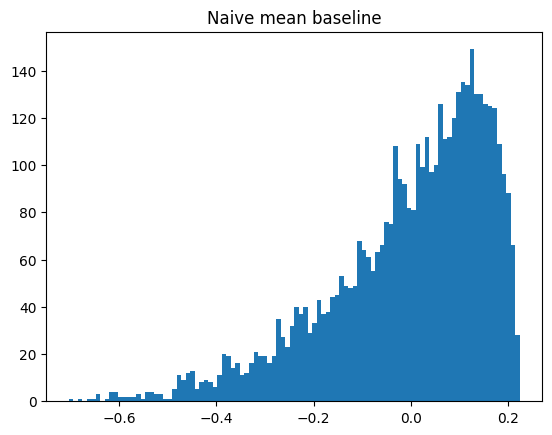

In [104]:
def gen_mean_predictor(y_train):
    avg = np.mean(y_train)

    def predict(X_test):
        return np.full(len(X_test), avg, dtype=float)

    return predict


pred = gen_mean_predictor(y_train)
y_pred = pred(X_test)
show_regression_report(y_test, y_pred, "Naive mean baseline")

Here are the results of our approach. It performs slightly better than the mean baseline, with residuals shifted closer to zero.

MSE = 0.021595545713221673
Avg diff = 0.11492668913911964


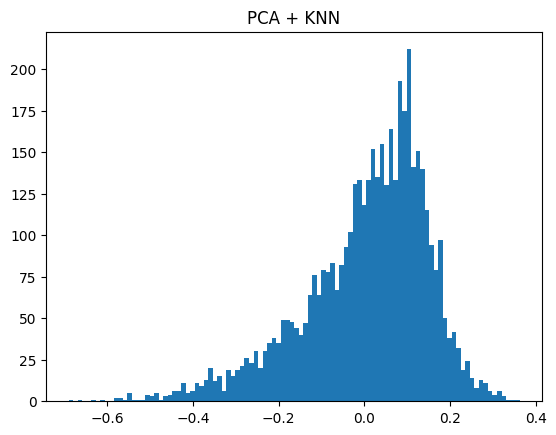

In [105]:
def gen_weighted_knn_predictor(X_train_pca, y_train, pca_model, feature_weights, n_neighbors=50):
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_pca * feature_weights, y_train)

    def predict(X_test):
        X_test_pca = pca_model.transform(X_test)
        return knn.predict(X_test_pca * feature_weights)

    return predict


pred = gen_weighted_knn_predictor(X_trn_pca, y_train, pca, best_params)
y_pred = pred(X_test)
show_regression_report(y_test, y_pred, "PCA + KNN")

MSE = 0.021739387200767537
Avg diff = 0.11284570269241162


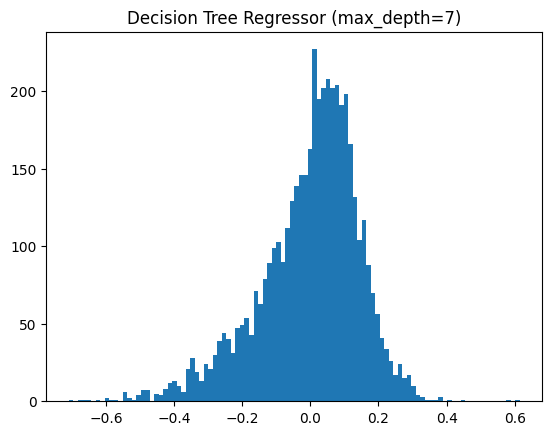

In [106]:
from sklearn import tree


fit_predict_evaluate(
    tree.DecisionTreeRegressor(max_depth=7),
    X_train,
    y_train,
    X_test,
    y_test,
    "Decision Tree Regressor (max_depth=7)",
)

MSE = 0.017483367022239033
Avg diff = 0.10077286691142412


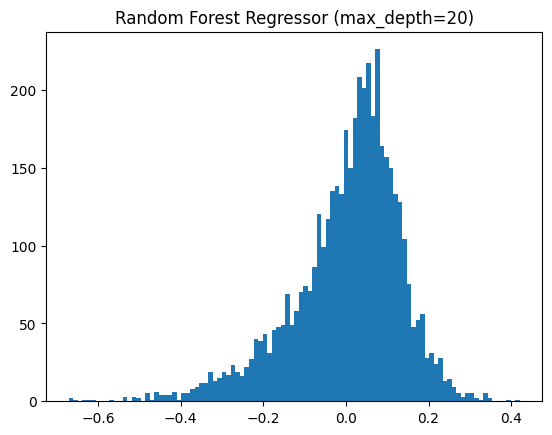

In [107]:
from sklearn.ensemble import RandomForestRegressor


fit_predict_evaluate(
    RandomForestRegressor(max_depth=20, random_state=123),
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest Regressor (max_depth=20)",
)

MSE = 0.019984967117961903
Avg diff = 0.108648760686046


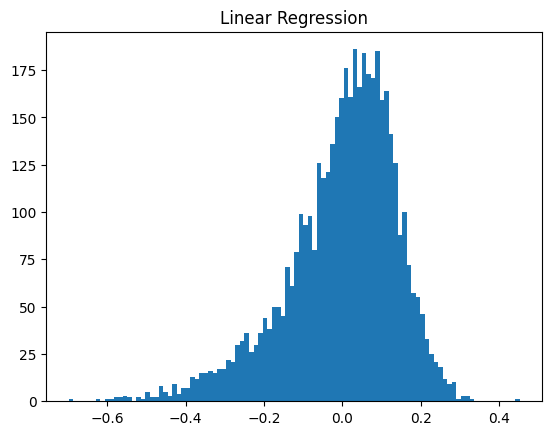

In [108]:
from sklearn.linear_model import LinearRegression


fit_predict_evaluate(
    LinearRegression(),
    X_train,
    y_train,
    X_test,
    y_test,
    "Linear Regression",
)

MSE = 0.01662835295370478
Avg diff = 0.09694347617229959


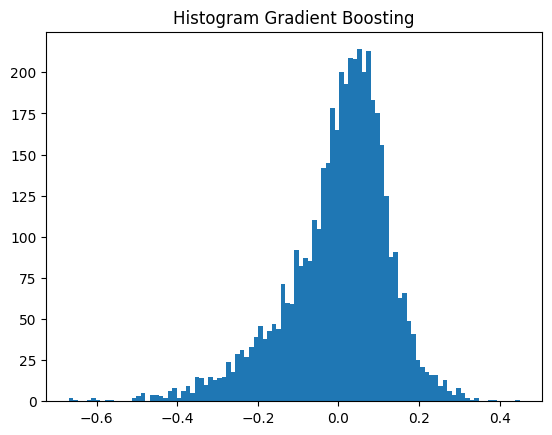

In [109]:
from sklearn.ensemble import HistGradientBoostingRegressor


fit_predict_evaluate(
    HistGradientBoostingRegressor(),
    X_train,
    y_train,
    X_test,
    y_test,
    "Histogram Gradient Boosting",
)